# SWMM Bellinge example

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import datetime
import pandas as pd
import matplotlib.dates as mdates

# temp import until the package is released
sys.path.insert(0, str(Path("../../src").resolve()))


import ewatercycle
from ewatercycle_swmm.model import SWMM

from ewatercycle.base.parameter_set import ParameterSet

/opt/conda/envs/ewatercycle2/lib/python3.12/site-packages/esmvalcore/experimental/_warnings.py:13: UserWarning: 
  Thank you for trying out the new ESMValCore API.
  Note that this API is experimental and may be subject to change.
  More info: https://github.com/ESMValGroup/ESMValCore/issues/498


## SWMM Input File

[SWMM](https://www.epa.gov/water-research/storm-water-management-model-swmm) works with input files, these are made with [QGIS](https://www.qgis.org/) or you can explore [this GitHub page](https://github.com/Jannik-Schilling/generate_swmm_inp).
Currently eWaterCycle does not support making the input files.

Any datafiles that are given inside the inputfile must also be in the same directory.
They will be automatically parsed to the model.

The input file has to be passed as a config to the eWaterCycle Parameterset:

In [2]:
current_dir = Path.cwd()

input_file = current_dir / "BellingeSWMM_v021_nopervious.inp"

parameters = ParameterSet(
    name="SWMM_parameter_files",
    directory=current_dir,
    config=Path(input_file),
    target_model='swmm',
)

## eWaterCycle model

Since the forcing data is inside the input file, we only need to parse the parameter set to the model.
Then we run the setup and initialize the container.

In [3]:
model = SWMM(parameter_set=parameters)
cfg_file, _ = model.setup()

In [4]:
model.initialize(cfg_file)

In [5]:
model.get_component_name()

'SWMM'

### Running the model

Using [BMI](https://bmi.csdms.io/en/stable/) we can interact with the eWaterCycle model.

I added a status bar as a nicety, it can be left out.

In [6]:
n_sc    = model.get_grid_size(0)
n_nodes = model.get_grid_size(1)
n_links = model.get_grid_size(2)

node_x = model.get_grid_x(1)   # node-grid x, model CRS — same order as node_flood columns
node_y = model.get_grid_y(1)   # node-grid y

times       = []
sc_runoff   = []
node_depth  = []
node_flood  = []
link_flow   = []

# This is for a status bar, not necessary
start, end = model.start_time, model.end_time
pbar = tqdm(total=end - start, unit="s", desc="SWMM run")
prev = model.time

while model.time < model.end_time:
    times.append(model.get_current_time())
    sc_runoff.append(model.get_value("subcatchment_runoff"))
    node_depth.append(model.get_value("node_depth"))
    node_flood.append(model.get_value("node_flooding"))
    link_flow.append(model.get_value("link_flow"))
    model.update()

    # Status bar
    pbar.update(model.time - prev)   # advance by the simulated seconds covered
    prev = model.time

# Status bar
pbar.close()

# Convert to arrays and a pandas time axis
hr         = pd.to_datetime([datetime.datetime.fromtimestamp(t, tz=datetime.timezone.utc) for t in times])
sc_runoff  = np.array(sc_runoff)   # shape: (n_steps, n_sc)
node_depth = np.array(node_depth)  # shape: (n_steps, n_nodes)
node_flood = np.array(node_flood)
link_flow  = np.array(link_flow)   # shape: (n_steps, n_links)

SWMM run:   0%|          | 0/172680.0 [00:00<?, ?s/s]

Since we take everything we need from the model already we can finalize already.

In [7]:
model.finalize()

### A map of the model

If you want there is a way to map your system.

In [8]:
# !pip install swmmio

In [9]:
import swmmio
from IPython.display import IFrame

map_html = 'swmm_map.html'

model_for_map = swmmio.Model(str(input_file), crs='epsg:3728')
swmmio.create_map(model_for_map, filename=map_html)

In [10]:
IFrame(map_html, width="100%", height=500)

## Flooding

Let us now look at the flooding of the nodes

Total flood volume : 1,000.0 m^3
Nodes flooded      : 395 / 1020
Peak system rate   : 2.028 m^3/s at 6.30 h


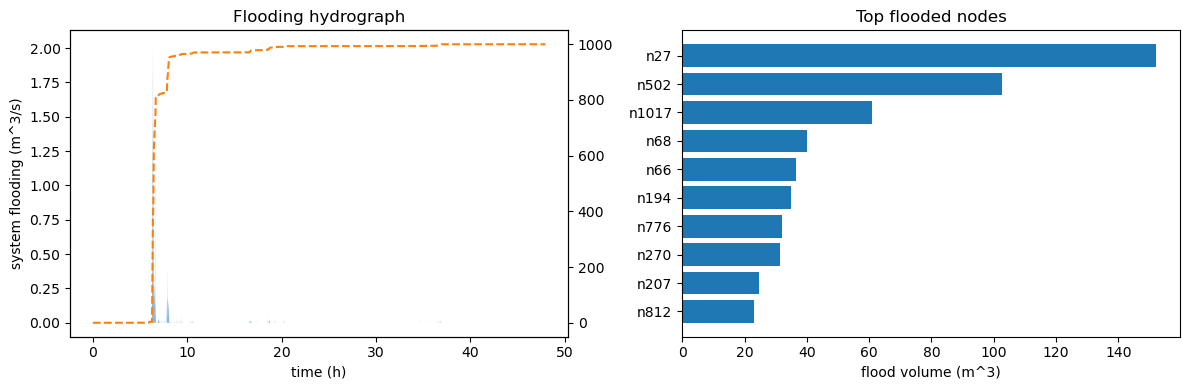

In [11]:
node_flood = np.clip(node_flood, 0, None)

dt = 4.0                                        # s between samples (your ROUTING_STEP)
t = np.arange(len(node_flood)) * dt / 3600      # hours

volume = np.trapz(node_flood, dx=dt, axis=0)       # m^3 per node (CMS -> m^3)
system_rate = node_flood.sum(axis=1)               # total flooding rate over time

print(f"Total flood volume : {volume.sum():,.1f} m^3")
print(f"Nodes flooded      : {(volume > 0).sum()} / {node_flood.shape[1]}")
print(f"Peak system rate   : {system_rate.max():.3f} m^3/s at {t[system_rate.argmax()]:.2f} h")

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
a1.fill_between(t, system_rate, alpha=0.5)
a1.set(xlabel="time (h)", ylabel="system flooding (m^3/s)", title="Flooding hydrograph")
a1.twinx().plot(t, np.cumsum(system_rate) * dt, "C1--")   # cumulative volume

top = np.argsort(volume)[::-1][:10]
a2.barh([f"n{i}" for i in top][::-1], volume[top][::-1])
a2.set(xlabel="flood volume (m^3)", title="Top flooded nodes")
plt.tight_layout(); plt.show()

Runoff volume generated : 26,004 m^3
Flood volume            : 1,000 m^3 (3.8% of runoff)
Nodes flooded           : 395 / 1020
Runoff->flood lag       : 1 min  (peak runoff 06:18, peak flood 06:19)


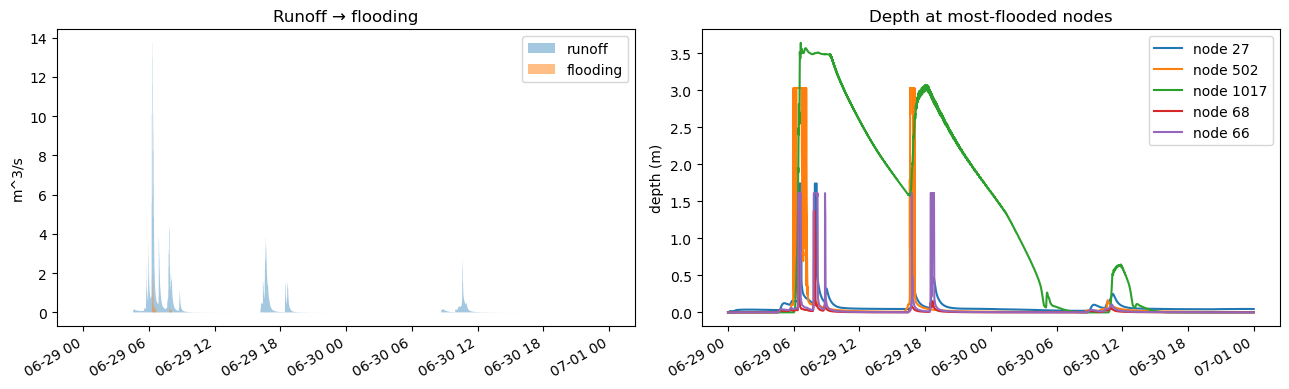

In [12]:
# --- assumes CMS flow units: flows are m^3/s (integrate to m^3); depths in m ---
t_s = (hr - hr[0]).total_seconds().to_numpy()         # seconds from run start
dt  = np.median(np.diff(t_s))

runoff_total = sc_runoff.sum(axis=1)                  # m^3/s generated
flood_total  = node_flood.clip(min=0).sum(axis=1)     # m^3/s lost to flooding
flood_vol    = np.trapz(node_flood.clip(min=0), x=t_s, axis=0)   # m^3 per node
runoff_vol   = np.trapz(runoff_total, x=t_s)             # m^3
flooded      = flood_vol > 0

print(f"Runoff volume generated : {runoff_vol:,.0f} m^3")
print(f"Flood volume            : {flood_vol.sum():,.0f} m^3 "
      f"({100*flood_vol.sum()/runoff_vol:.1f}% of runoff)")
print(f"Nodes flooded           : {flooded.sum()} / {node_flood.shape[1]}")

# runoff -> flood response lag via cross-correlation
a = runoff_total - runoff_total.mean()
b = flood_total  - flood_total.mean()
xc = np.correlate(b, a, mode="full")
lag = np.arange(-len(a) + 1, len(a))[xc.argmax()] * dt / 60
print(f"Runoff->flood lag       : {lag:.0f} min  "
      f"(peak runoff {hr[runoff_total.argmax()]:%H:%M}, "
      f"peak flood {hr[flood_total.argmax()]:%H:%M})")

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].fill_between(hr, runoff_total, alpha=0.4, label="runoff")
ax[0].fill_between(hr, flood_total,  alpha=0.5, label="flooding")
ax[0].set(ylabel="m^3/s", title="Runoff \u2192 flooding"); ax[0].legend()

top = np.argsort(flood_vol)[::-1][:5]
for i in top[flood_vol[top] > 0]:
    ax[1].plot(hr, node_depth[:, i], label=f"node {i}")
ax[1].set(ylabel="depth (m)", title="Depth at most-flooded nodes"); ax[1].legend()
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

### Optional: fill in the map

Let's have some fun with the map.
We will encircle the nodes that experience flooding.

In [13]:
# !pip install folium

In [14]:
import folium

MODEL_CRS = "EPSG:25832"

model_for_map = swmmio.Model(str(input_file), crs=MODEL_CRS)
model_for_map.to_crs("EPSG:4326")
nd = model_for_map.nodes.dataframe
pts = np.array([c[0] for c in nd["coords"]])      # (lon, lat) per node, swmmio order
lon, lat = pts[:, 0], pts[:, 1]

assert len(lon) == node_flood.shape[1], "node count mismatch — column alignment broken"

fmap = folium.Map(location=[float(lat.mean()), float(lon.mean())],
                  zoom_start=15, tiles="CartoDB positron")
folium.GeoJson(model_for_map.links.geojson, name="conduits",
               style_function=lambda f: {"color": "#3b6ea5", "weight": 2}).add_to(fmap)
for i in range(len(lat)):
    folium.CircleMarker([lat[i], lon[i]], radius=2, color="#555",
                        fill=True, fill_opacity=0.8).add_to(fmap)
for i in np.where(flood_vol > 0)[0]:
    folium.Circle([lat[i], lon[i]], radius=40, color="red", weight=3,
                  fill=True, fill_opacity=0.25,
                  popup=f"node {i}: {flood_vol[i]:,.0f} m^3").add_to(fmap)
folium.LayerControl().add_to(fmap)
fmap